Training samples: 1270501
Testing samples: 141167
[0]	validation_0-rmse:3.70304	validation_0-mae:3.33674
[100]	validation_0-rmse:1.63357	validation_0-mae:1.41278
[200]	validation_0-rmse:1.01713	validation_0-mae:0.77462
[300]	validation_0-rmse:0.84660	validation_0-mae:0.59349
[400]	validation_0-rmse:0.81961	validation_0-mae:0.55167
[500]	validation_0-rmse:0.81677	validation_0-mae:0.54790
[516]	validation_0-rmse:0.81695	validation_0-mae:0.54814

Test MSE: 0.666960
Test RMSE: 0.816676 °C
Test MAE: 0.547755 °C
Test R²: 0.818772
Variance explained: 81.88%


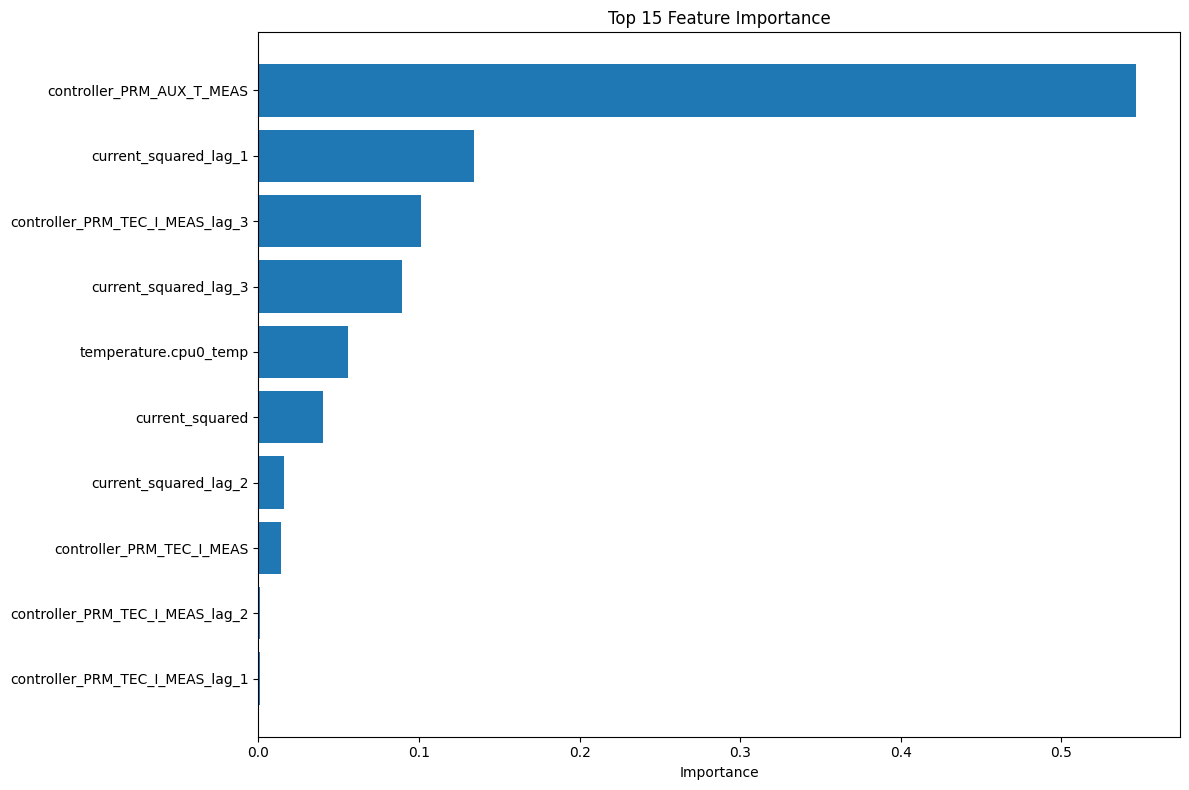

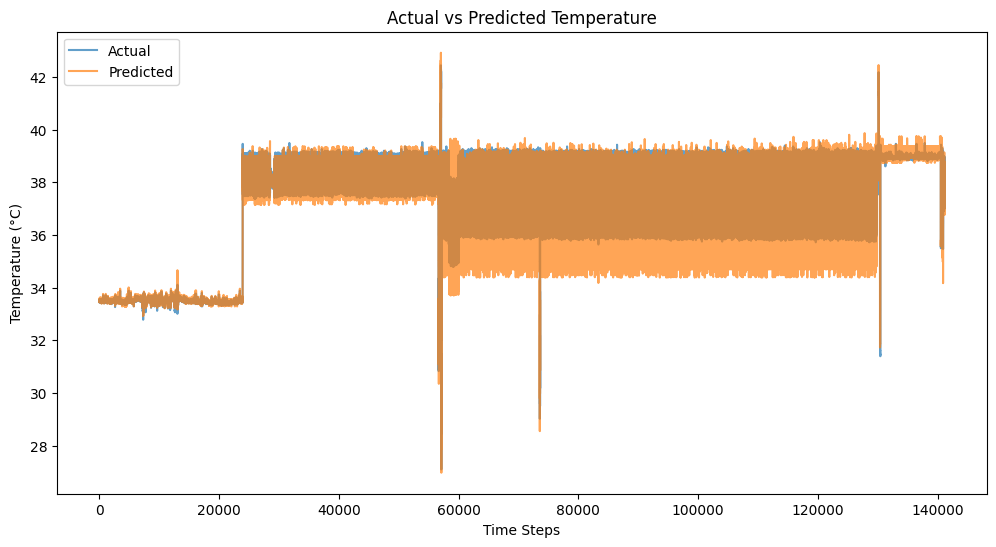

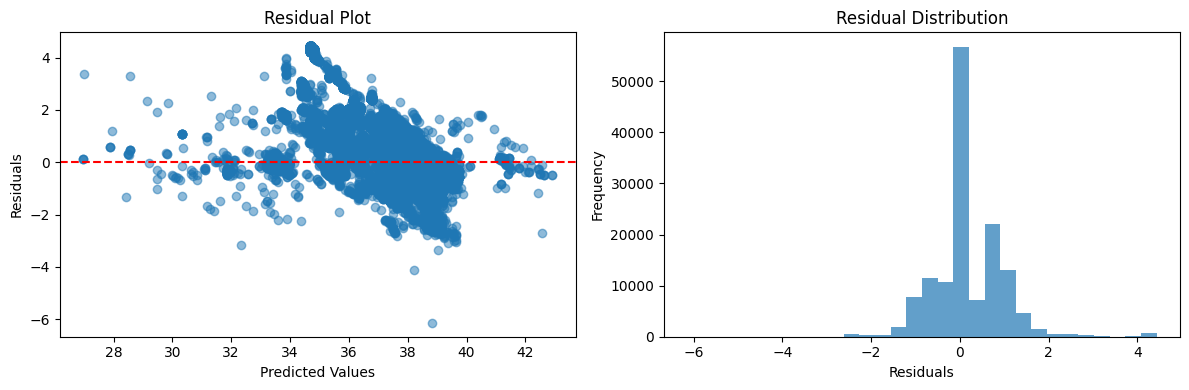

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Load dataset
# -----------------------------
# df = pd.read_csv('C:\\Work\\Thermal Model\\BladeB\\Data Extraction\\my_data_pivot_ratio.csv', parse_dates=['timestamp'])
df = pd.read_csv('C:\\Work\\Thermal Model\\BladeB\\Data Extraction\\my_overall_batch_pivot.csv', parse_dates=['timestamp'])

df = df.sort_values('timestamp').reset_index(drop=True)

# -----------------------------
# Step 2: Create lag features based on correlation analysis
# -----------------------------
# Add physics-informed features before creating lag features
df['current_squared'] = df['controller_PRM_TEC_I_MEAS'] ** 2
# df['current_times_temp'] = df['controller_PRM_TEC_I_MEAS'] * df['controller_PRM_AUX_T_MEAS']
# df['cooling_power_estimate'] = df['controller_PRM_TEC_I_MEAS'] * (df['controller_PRM_AUX_T_MEAS'] - df['temperature.cpu0_temp'])
# # Define which features to create lags for (based on correlation map)
features_to_lag = [
    # 'controller_PRM_AUX_T_MEAS',  # Target variable
    # 'controller_PRM_FBK_T_MEAS',  # High correlation with target (0.95)
    'controller_PRM_TEC_I_MEAS',  # Moderate correlation with target (-0.38)
    # 'temperature.cpu0_temp',      # Good correlation with target (0.46)
    # 'load_avg.1m',                # Good correlation with target (0.40)
    # 'total_cpu_usage.usr'         # Moderate correlation with target (0.30)
]
# # Add these to your features_to_lag list
features_to_lag.extend(['current_squared'])
# # features_to_lag.extend(['current_squared', 'current_times_temp'])
# # # features_to_lag.extend([ 'cooling_power_estimate'])
# # Create lag features (1-5 steps back)
for feature in features_to_lag:
    for lag in range(1, 4):  # Create lags from 1 to 5 steps back
        df[f'{feature}_lag_{lag}'] = df[feature].shift(lag)

# Create the target variable (next time step)
df['T_aux_next'] = df['controller_PRM_AUX_T_MEAS'].shift(-1)

# Remove rows with NaN values created by shifting
df = df.dropna()

# -----------------------------
# Step 3: Prepare features and target
# -----------------------------


# 80 % accuracy
# all_features = [
#     'controller_PRM_AUX_T_MEAS',
#     'total_cpu_usage.idl',
#     'total_cpu_usage.sys',
#     'aperf',
#     # 'mperf',
#     'controller_PRM_FBK_T_MEAS', 
#     'controller_PRM_TEC_I_MEAS',
#     'temperature.cpu0_temp',
#     'load_avg.1m',
#     # 'load_avg.5m',
#     # 'load_avg.15m',
#     'total_cpu_usage.usr',
#     # 'ratio'
# ]


# Select features for model training (include original features and lag features)
all_features = [
    'controller_PRM_AUX_T_MEAS',
    # # 'controller_PRM_FLOW_MEAS',
    # # 'total_cpu_usage.idl',
    'current_squared',
    # 'current_times_temp',
    # # 'cooling_power_estimate',
    # 'total_cpu_usage.sys',
    # 'aperf',
    # 'mperf',
    # 'controller_PRM_FBK_T_MEAS', 
    'controller_PRM_TEC_I_MEAS',
    'temperature.cpu0_temp',
    # 'load_avg.1m',
    # 'load_avg.5m',
    # 'load_avg.15m',
    # 'total_cpu_usage.usr',
    # 'ratio'
]

# # # Add all lag features to the feature list
for feature in features_to_lag:
    for lag in range(1, 4):
        all_features.append(f'{feature}_lag_{lag}')

# Prepare data
X = df[all_features]
y = df['T_aux_next']

# -----------------------------
# Step 4: Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, shuffle=False, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# -----------------------------
# Step 5: Scale the features
# -----------------------------
scaler = StandardScaler()
# scaler = MinMaxScaler()
# scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
monotone_constraints = []
for feature in all_features:
    if feature in [ 'controller_PRM_TEC_I_MEAS', 'current_squared','current_times_temp', 
                   'controller_PRM_TEC_I_MEAS_lag_1', 'current_squared_lag_1', 'controller_PRM_TEC_I_MEAS_lag_2',
                     'current_squared_lag_2', 'controller_PRM_TEC_I_MEAS_lag_3', 'current_squared_lag_3',]:
        monotone_constraints.append(-1)
    elif feature in ['temperature.cpu0_temp', 'temperature.cpu0_temp_lag_1',
                      'temperature.cpu0_temp_lag_2','temperature.cpu0_temp_lag_3']:
        monotone_constraints.append(1)
    else:
        monotone_constraints.append(0)

monotone_constraints = tuple(monotone_constraints)
# -----------------------------
# Step 6: Train XGBoost model
# -----------------------------
# Define XGBoost model
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.0099,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    monotone_constraints=monotone_constraints,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric=['rmse', 'mae']
)

# model = xgb.XGBRegressor(
#     n_estimators=1498,
#     learning_rate=0.08859239906772673,
#     max_depth=12,
#     subsample=0.717764954505080,
#     colsample_bytree=0.734768667220199,
#     reg_alpha=1.3459958950555766,
#     reg_lambda=8.328313584928534,
#     random_state=42,
#     early_stopping_rounds=50,
#     eval_metric=['rmse', 'mae']
# )

# Train the model
model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=100
)

# -----------------------------
# Step 7: Evaluate the model
# -----------------------------
y_pred = model.predict(X_test_scaled)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nTest MSE: {mse:.6f}")
print(f"Test RMSE: {rmse:.6f} °C")
print(f"Test MAE: {mae:.6f} °C")
print(f"Test R²: {r2:.6f}")
print(f"Variance explained: {r2*100:.2f}%")



# -----------------------------
# Step 8: Feature importance
# -----------------------------
# Plot feature importance
feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# -----------------------------
# Step 9: Plot predictions vs actual
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

# -----------------------------
# Step 10: Residual analysis
# -----------------------------
residuals = y_test - y_pred
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

[0]	validation_0-rmse:3.54807	validation_0-mae:2.08377
[100]	validation_0-rmse:2.00189	validation_0-mae:1.55745
[200]	validation_0-rmse:1.73745	validation_0-mae:1.46600
[300]	validation_0-rmse:1.70865	validation_0-mae:1.40796
[400]	validation_0-rmse:1.70379	validation_0-mae:1.37101
[500]	validation_0-rmse:1.70539	validation_0-mae:1.35574
[600]	validation_0-rmse:1.70760	validation_0-mae:1.34925
[696]	validation_0-rmse:1.70956	validation_0-mae:1.34852

Test MSE: 2.919028
Test RMSE: 1.708516 °C
Test MAE: 1.347406 °C
Test R²: 0.764793
Variance explained: 76.48%


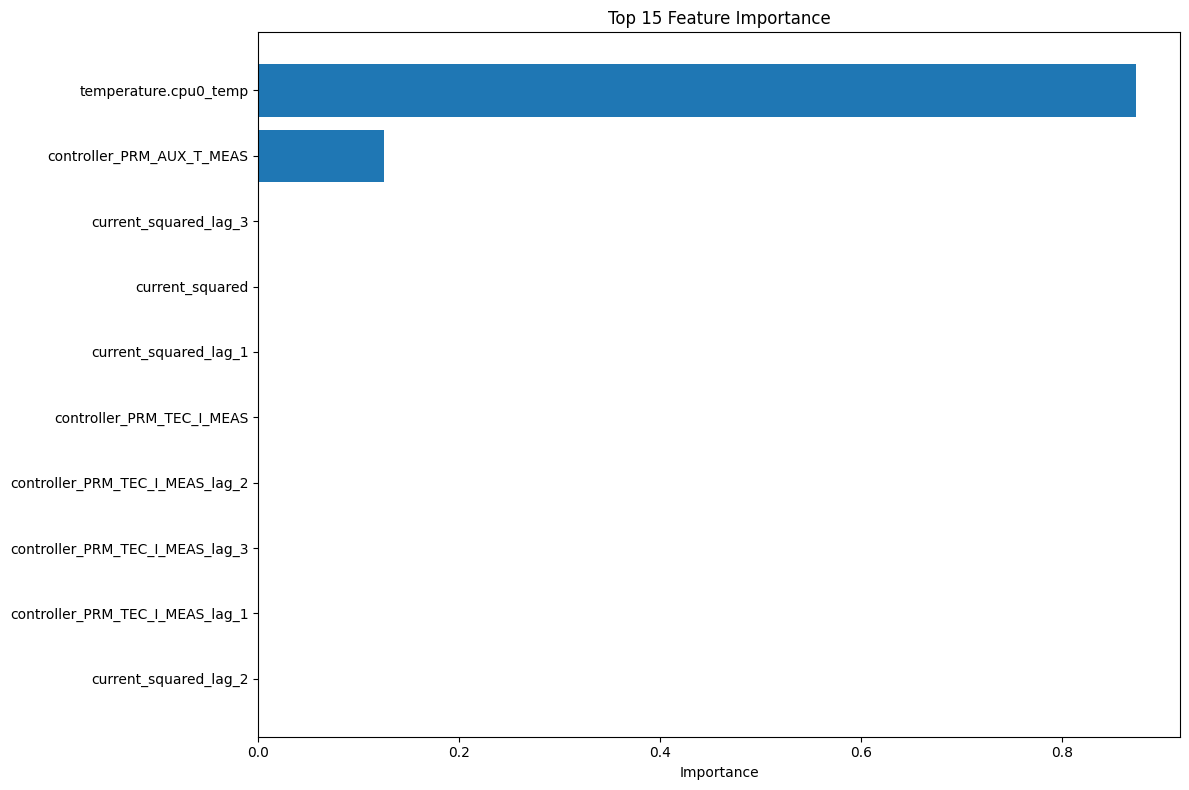

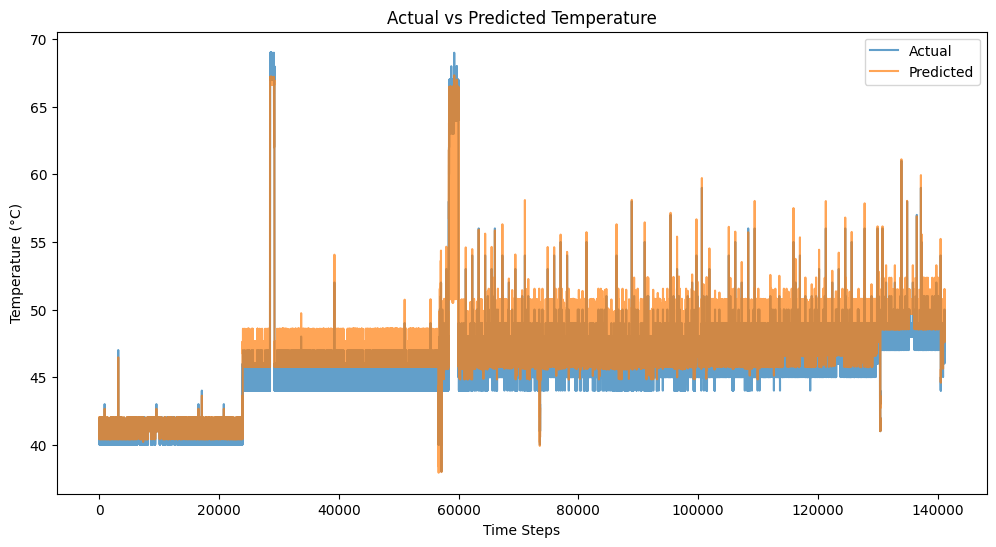

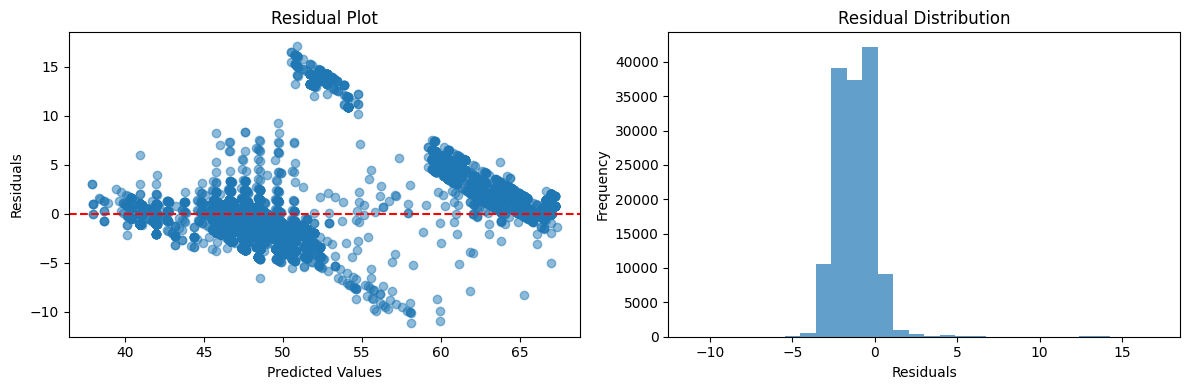

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Load dataset
# -----------------------------
# df = pd.read_csv('C:\\Work\\Thermal Model\\BladeB\\Data Extraction\\my_data_pivot_ratio.csv', parse_dates=['timestamp'])
df = pd.read_csv('C:\\Work\\Thermal Model\\BladeB\\Data Extraction\\my_overall_batch_pivot.csv', parse_dates=['timestamp'])

df = df.sort_values('timestamp').reset_index(drop=True)

# -----------------------------
# Step 2: Create lag features based on correlation analysis
# -----------------------------
# Add physics-informed features before creating lag features
df['current_squared'] = df['controller_PRM_TEC_I_MEAS'] ** 2
# df['current_times_temp'] = df['controller_PRM_TEC_I_MEAS'] * df['controller_PRM_AUX_T_MEAS']
# df['cooling_power_estimate'] = df['controller_PRM_TEC_I_MEAS'] * (df['controller_PRM_AUX_T_MEAS'] - df['temperature.cpu0_temp'])
# # Define which features to create lags for (based on correlation map)
features_to_lag = [
    # 'controller_PRM_AUX_T_MEAS',  # Target variable
    # 'controller_PRM_FBK_T_MEAS',  # High correlation with target (0.95)
    'controller_PRM_TEC_I_MEAS',  # Moderate correlation with target (-0.38)
    # 'temperature.cpu0_temp',      # Good correlation with target (0.46)
    # 'load_avg.1m',                # Good correlation with target (0.40)
    # 'total_cpu_usage.usr'         # Moderate correlation with target (0.30)
]
# # Add these to your features_to_lag list
features_to_lag.extend(['current_squared'])
# # features_to_lag.extend(['current_squared', 'current_times_temp'])
# # # features_to_lag.extend([ 'cooling_power_estimate'])
# # Create lag features (1-5 steps back)
for feature in features_to_lag:
    for lag in range(1, 4):  # Create lags from 1 to 5 steps back
        df[f'{feature}_lag_{lag}'] = df[feature].shift(lag)

# Create the target variable (next time step)
# df['T_aux_next'] = df['controller_PRM_AUX_T_MEAS'].shift(-1)
df['T_cpu_next'] = df['temperature.cpu0_temp'].shift(-1)
# Remove rows with NaN values created by shifting
df = df.dropna()




# Select features for model training (include original features and lag features)
all_features = [
    'controller_PRM_AUX_T_MEAS',
    'current_squared',
    'controller_PRM_TEC_I_MEAS',
    'temperature.cpu0_temp',
]

# # # Add all lag features to the feature list
for feature in features_to_lag:
    for lag in range(1, 4):
        all_features.append(f'{feature}_lag_{lag}')

# Prepare data
X_cpu = df[all_features]
y_cpu = df['T_cpu_next']

# -----------------------------
# Step 4: Train-test split
# -----------------------------
X_cpu_train, X_cpu_test, y_cpu_train, y_cpu_test = train_test_split(
    X_cpu, y_cpu, test_size=0.10, shuffle=False, random_state=42
)

# -----------------------------
# Step 5: Scale the features
# -----------------------------
scaler_cpu = StandardScaler()
# scaler = MinMaxScaler()
# scaler = RobustScaler()
X_cpu_train_scaled = scaler_cpu.fit_transform(X_cpu_train)
X_cpu_test_scaled = scaler_cpu.transform(X_cpu_test)
monotone_constraints = []
for feature in all_features:
    if feature in [ 'controller_PRM_TEC_I_MEAS', 'current_squared',
                   'controller_PRM_TEC_I_MEAS_lag_1', 'current_squared_lag_1', 'controller_PRM_TEC_I_MEAS_lag_2',
                   'current_squared_lag_2', 'controller_PRM_TEC_I_MEAS_lag_3', 'current_squared_lag_3']:
        monotone_constraints.append(-1)
    elif feature in ['controller_PRM_AUX_T_MEAS']:
        monotone_constraints.append(1)
    else:
        monotone_constraints.append(0)

monotone_constraints = tuple(monotone_constraints)
# -----------------------------
# Step 6: Train XGBoost model
# -----------------------------
# Define XGBoost model
model_cpu = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.0099,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    monotone_constraints=monotone_constraints,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric=['rmse', 'mae']
)

model_cpu.fit(
    X_cpu_train_scaled, y_cpu_train,
    eval_set=[(X_cpu_test_scaled, y_cpu_test)],
    verbose=100
)

# -----------------------------
# Step 7: Evaluate the model
# -----------------------------
y_cpu_pred = model_cpu.predict(X_cpu_test_scaled)

# Calculate metrics
mse = mean_squared_error(y_cpu_test, y_cpu_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_cpu_test, y_cpu_pred)
r2 = r2_score(y_cpu_test, y_cpu_pred)

print(f"\nTest MSE: {mse:.6f}")
print(f"Test RMSE: {rmse:.6f} °C")
print(f"Test MAE: {mae:.6f} °C")
print(f"Test R²: {r2:.6f}")
print(f"Variance explained: {r2*100:.2f}%")



# -----------------------------
# Step 8: Feature importance
# -----------------------------
# Plot feature importance
feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': model_cpu.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# -----------------------------
# Step 9: Plot predictions vs actual
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(y_cpu_test.values, label='Actual', alpha=0.7)
plt.plot(y_cpu_pred, label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

# -----------------------------
# Step 10: Residual analysis
# -----------------------------
residuals = y_cpu_test - y_cpu_pred
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_cpu_pred, residuals, alpha=0.5)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

In [5]:
import joblib
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(model_cpu, 'model_cpu.pkl')
joblib.dump(scaler_cpu, 'scaler_cpu.pkl')

['scaler_cpu.pkl']

In [6]:
import joblib
# load the trained model and scaler
model = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')
model_cpu = joblib.load('model_cpu.pkl')
scaler_cpu = joblib.load('scaler_cpu.pkl')